In [1]:
from google.colab import drive
drive.mount('/content/drive/')


Mounted at /content/drive/


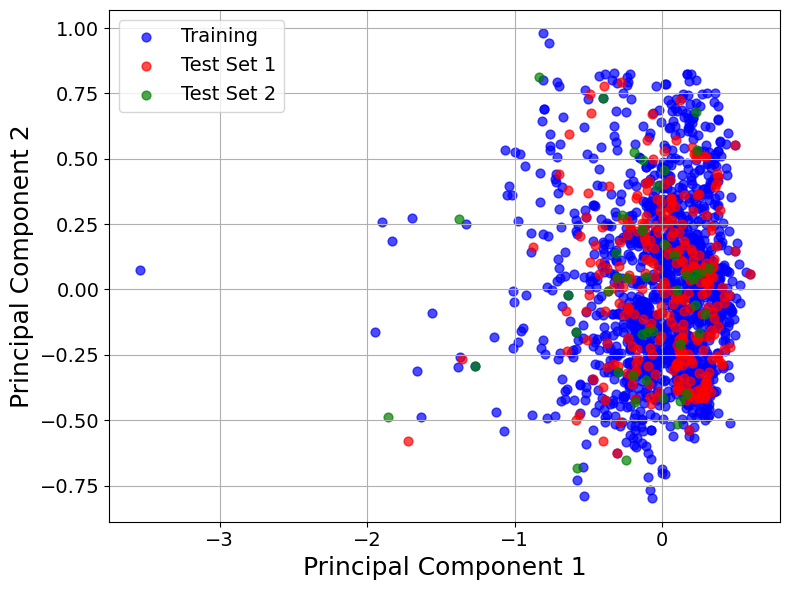

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

# Load data
training_data = pd.read_excel(
    '/content/drive/MyDrive/HOB_revised1/plot_data.xlsx',
    sheet_name='train'
)

test_data1 = pd.read_excel(
    '/content/drive/MyDrive/HOB_revised1/plot_data.xlsx',
    sheet_name='test1'
)

test_data2 = pd.read_excel(
    '/content/drive/MyDrive/HOB_revised1/plot_data.xlsx',
    sheet_name='test2'
)

def preprocess_classification(X):
    X = X.copy()
    X.replace([np.inf, -np.inf], np.finfo(np.float64).max, inplace=True)

    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(X)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    return X_scaled

# Combine all datasets
combined_data = pd.concat(
    [training_data, test_data1, test_data2],
    axis=0,
    ignore_index=True
)

combined_data_scaled = preprocess_classification(combined_data)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_data_scaled)

# Number of samples
n_train = len(training_data)
n_test1 = len(test_data1)
n_test2 = len(test_data2)

# Split PCA results
pca_train = pca_result[:n_train]
pca_test1 = pca_result[n_train:n_train+n_test1]
pca_test2 = pca_result[n_train+n_test1:]

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    pca_train[:,0],
    pca_train[:,1],
    color='blue',
    alpha=0.7,
    s=40,
    marker='o',
    label='Training'
)

plt.scatter(
    pca_test1[:,0],
    pca_test1[:,1],
    color='red',
    alpha=0.7,
    s=40,
    marker='o',
    label='Test Set 1'
)

plt.scatter(
    pca_test2[:,0],
    pca_test2[:,1],
    color='green',
    alpha=0.7,
    s=40,
    marker='o',
    label='Test Set 2'
)

plt.xlabel('Principal Component 1', fontsize=18)
plt.ylabel('Principal Component 2', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14)
plt.grid(True)

plt.tight_layout()

plt.savefig('/content/drive/MyDrive/HOB_revised1/pca_three_sets.png',
            dpi=300, bbox_inches='tight')
plt.savefig('/content/drive/MyDrive/HOB_revised1/pca_three_sets.eps',
            format='eps', bbox_inches='tight')

plt.show()

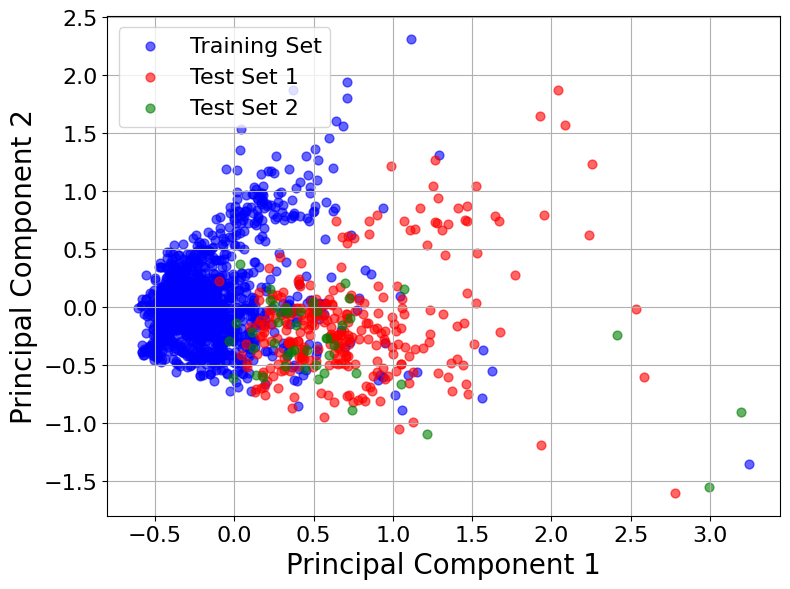

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

# Load datasets
training_data = pd.read_csv('/content/drive/MyDrive/HOB_revised1/train_merged_array.csv')
test_data1 = pd.read_csv('/content/drive/MyDrive/HOB_revised1/test1_merged_array.csv')
test_data2 = pd.read_csv('/content/drive/MyDrive/HOB_revised1/test2_merged_array.csv')

def preprocess_classification(X):
    X = X.copy()
    X.replace([np.inf, -np.inf], np.finfo(np.float64).max, inplace=True)

    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)

    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)

    return X

# Combine all datasets
combined_data = pd.concat(
    [training_data, test_data1, test_data2],
    axis=0,
    ignore_index=True
)

combined_data_scaled = preprocess_classification(combined_data)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_data_scaled)

# Split PCA results
n_train = len(training_data)
n_test1 = len(test_data1)
n_test2 = len(test_data2)

pca_train = pca_result[:n_train]
pca_test1 = pca_result[n_train:n_train+n_test1]
pca_test2 = pca_result[n_train+n_test1:]

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    pca_train[:,0],
    pca_train[:,1],
    color='blue',
    alpha=0.6,
    s=40,
    label='Training Set'
)

plt.scatter(
    pca_test1[:,0],
    pca_test1[:,1],
    color='red',
    alpha=0.6,
    s=40,
    label='Test Set 1'
)

plt.scatter(
    pca_test2[:,0],
    pca_test2[:,1],
    color='green',
    alpha=0.6,
    s=40,
    label='Test Set 2'
)

plt.xlabel('Principal Component 1', fontsize=20)
plt.ylabel('Principal Component 2', fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/HOB_revised1/pca_cfm.png',
            dpi=300,
            bbox_inches='tight')

plt.savefig('/content/drive/MyDrive/HOB_revised1/pca_cfm.eps',
            format='eps',
            bbox_inches='tight')

plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, balanced_accuracy_score

# Load CSV file
df = pd.read_excel('/content/drive/MyDrive/HOB/comparison_SOTA.xlsx', sheet_name = "ADMETSAR_use")



In [ ]:
df

,Unnamed: 0,ADMET SAR 20%,ADMET SAR 50%,Actual
0,CCCC1=NC(=C2N1N=C(NC2=O)C3=C(C=CC(=C3)S(=O)(=O...,1,0,0
1,CCCC1=NN(C2=C1N=C(NC2=O)C3=C(C=CC(=C3)S(=O)(=O...,1,0,1
2,CCCNCC(COC1=CC=CC=C1C(=O)CCC2=CC=CC=C2)O,1,0,1
3,CN(C)CC(C1=CC=C(C=C1)OC)C2(CCCCC2)O,1,1,1
4,C1CC1CN2CCC34C5C(=O)CCC3(C2CC6=C4C(=C(C=C6)O)O5)O,1,0,1
5,C1CCC(C(C1)CN2CCN(CC2)C3=NSC4=CC=CC=C43)CN5C(=...,0,0,0
6,CC1(COC(C(C1NC)O)OC2C(CC(C(C2O)OC3C(CC=C(O3)CN...,0,0,0
7,CCC1(CC(C(=O)O)C(=O)O)C(=O)N1CC2=CC=CC=C2,1,1,1
8,CC(C)(C)C1=C(C=CC(=C1)C2=C(C=CC(=C2)C3=CC=C(C=...,1,1,0
9,CC(C)CCCCCCCCC(=O)NC1C(C(C(OC1OC2=C3C=C4C=C2OC...,0,0,0


In [ ]:
# Extract true and predicted labels
true_labels = df['Actual']
predicted_labels = df['ADMET SAR 20%']



In [ ]:
# Compute metrics
accuracy = accuracy_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
balanced_acc = balanced_accuracy_score(true_labels, predicted_labels)

# If the problem is binary classification, compute AUC
# Ensure that 'predicted_labels' are probabilities if using ROC AUC
try:
    auc = roc_auc_score(true_labels, predicted_labels)
except ValueError:
    auc = 'AUC not applicable for this case (requires probabilities for ROC)'

# Print the results
print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'Balanced Accuracy: {balanced_acc:.4f}')
print(f'AUC: {auc}')


Accuracy: 0.6818
F1 Score: 0.7742
Precision: 0.7059
Recall: 0.8571
Balanced Accuracy: 0.6161
AUC: 0.6160714285714286


In [ ]:
#Ranking analysis of FM and CFM
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

df = pd.read_excel('/content/drive/MyDrive/HOB/Rerun/fm_cfm.xlsx', sheet_name = "test_best_smote")
print(df)

metrics = ['acc', 'auc', 'bcc', 'recall', 'prec', 'f1']
fm_ranks = []
cfm_ranks = []
p_values = []

for metric in metrics:
    fm_column = f'FM_{metric}'
    cfm_column = f'CFM_{metric}'
    ranks = df[[fm_column, cfm_column]].rank(axis=1, method='min', ascending=False)
    print(ranks)
    fm_rank_mean = ranks[fm_column].mean()
    cfm_rank_mean = ranks[cfm_column].mean()

    # Perform Wilcoxon signed-rank test
    stat, p_value = wilcoxon(df[fm_column], df[cfm_column])

    # Append the results
    fm_ranks.append(fm_rank_mean)
    cfm_ranks.append(cfm_rank_mean)
    p_values.append(p_value)

# Create a summary DataFrame for the results
summary_df = pd.DataFrame({
    'Metric': metrics,
    'FM Mean Rank': fm_ranks,
    'CFM Mean Rank': cfm_ranks,
    'p-value': p_values
})

# Display the results
print(summary_df)

# Determine if CFM is significantly better based on p-value < 0.05
summary_df['Significant Improvement'] = summary_df['p-value'] < 0.05
print("\nStatistical Significance Summary:")
print(summary_df[['Metric', 'p-value', 'Significant Improvement']])

# Save the results to an Excel file
#output_file = '/mnt/data/analysis_results.xlsx'
#summary_df.to_excel(output_file, index=False)
#print(f"\nAnalysis results saved to: {output_file}")


    FM_acc  CFM_acc
0      2.0      1.0
1      2.0      1.0
2      2.0      1.0
3      1.0      2.0
4      2.0      1.0
5      2.0      1.0
6      2.0      1.0
7      1.0      2.0
8      1.0      2.0
9      1.0      2.0
10     2.0      1.0
    FM_auc  CFM_auc
0      1.0      2.0
1      2.0      1.0
2      2.0      1.0
3      1.0      2.0
4      2.0      1.0
5      2.0      1.0
6      2.0      1.0
7      1.0      2.0
8      1.0      2.0
9      1.0      2.0
10     2.0      1.0
    FM_bcc  CFM_bcc
0      2.0      1.0
1      2.0      1.0
2      2.0      1.0
3      1.0      2.0
4      2.0      1.0
5      2.0      1.0
6      2.0      1.0
7      1.0      2.0
8      1.0      2.0
9      2.0      1.0
10     2.0      1.0
    FM_recall  CFM_recall
0         1.0         2.0
1         1.0         2.0
2         1.0         2.0
3         1.0         1.0
4         2.0         1.0
5         1.0         2.0
6         2.0         1.0
7         1.0         2.0
8         1.0         2.0
9         1.0       

In [7]:
#Ranking analysis of FM and CFM
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

df = pd.read_excel('/content/drive/MyDrive/HOB_revised1/algo_rank.xlsx', sheet_name = "cv_none")
print(df)

algos = ['RF', 'SVM', 'KNN', 'DT', 'LR', 'GB','NB', 'AdaBoost', 'EGB', 'CatBoost', 'BioGCN']

rf_ranks = []
svm_ranks = []
knn_ranks = []
dt_ranks = []
lr_ranks = []
gb_ranks = []
nb_ranks = []
adaboost_ranks = []
egb_ranks = []
catboost_ranks = []
biogcn_ranks = []
p_values = []

for algo in algos:
    rf_column = f'{algo}'
    svm_column = f'{algo}'
    knn_column = f'{algo}'
    dt_column = f'{algo}'
    lr_column = f'{algo}'
    gb_column = f'{algo}'
    nb_column = f'{algo}'
    adaboost_column = f'{algo}'
    egb_column = f'{algo}'
    catboost_column = f'{algo}'
    biogcn_column = f'{algo}'

    ranks = df[[rf_column, svm_column, knn_column, dt_column, lr_column, gb_column, nb_column, adaboost_column, egb_column, catboost_column, biogcn_column]].rank(axis=1, method='min', ascending=False)
    print(ranks)
    rf_rank_mean = ranks[rf_column].mean()
    svm_rank_mean = ranks[svm_column].mean()
    knn_rank_mean = ranks[knn_column].mean()
    dt_rank_mean = ranks[dt_column].mean()
    lr_rank_mean = ranks[lr_column].mean()
    gb_rank_mean = ranks[gb_column].mean()
    nb_rank_mean = ranks[nb_column].mean()
    adaboost_rank_mean = ranks[adaboost_column].mean()
    egb_rank_mean = ranks[egb_column].mean()
    catboost_rank_mean = ranks[catboost_column].mean()
    biogcn_rank_mean = ranks[biogcn_column].mean()


    # Perform Wilcoxon signed-rank test
  #  stat, p_value = wilcoxon(df[fm_column], df[cfm_column])

    # Append the results
    rf_ranks.append(rf_rank_mean)
    svm_ranks.append(svm_rank_mean)
    knn_ranks.append(knn_rank_mean)
    dt_ranks.append(dt_rank_mean)
    lr_ranks.append(lr_rank_mean)
    gb_ranks.append(gb_rank_mean)
    nb_ranks.append(nb_rank_mean)
    adaboost_ranks.append(adaboost_rank_mean)
    egb_ranks.append(egb_rank_mean)
    catboost_ranks.append(catboost_rank_mean)
    biogcn_ranks.append(biogcn_rank_mean)



# Create a summary DataFrame for the results
summary_df = pd.DataFrame({
    'Algo': algos,
    'RF Mean Rank': rf_ranks,
    'SVM Mean Rank': svm_ranks,
    'KNN Mean Rank': knn_ranks,
    'DT Mean Rank': dt_ranks,
    'LR Mean Rank': lr_ranks,
    'GB Mean Rank': gb_ranks,
    'NB Mean Rank': nb_ranks,
    'AdaBoost Mean Rank': adaboost_ranks,
    'EGB Mean Rank': egb_ranks,
    'CatBoost Mean Rank': catboost_ranks,
    'BioGCN Mean Rank': biogcn_ranks
})

# Display the results
print(summary_df)

# Determine if CFM is significantly better based on p-value < 0.05
#summary_df['Significant Improvement'] = summary_df['p-value'] < 0.05
#print("\nStatistical Significance Summary:")
#print(summary_df[['Algo', 'p-value', 'Significant Improvement']])

# Save the results to an Excel file
#output_file = '/mnt/data/analysis_results.xlsx'
#summary_df.to_excel(output_file, index=False)
#print(f"\nAnalysis results saved to: {output_file}")


  Unnamed: 0      RF     SVM     KNN      DT      LR      GB      NB  \
0   Accuracy  0.7816  0.7610  0.7670  0.7413  0.7751  0.7789  0.5293   
1        AUC  0.7633  0.7181  0.6961  0.6146  0.7347  0.7254  0.6008   
2        Bcc  0.5981  0.5971  0.5515  0.6041  0.6178  0.5988  0.6008   
3     Recall  0.9594  0.9203  0.9755  0.8752  0.9281  0.9538  0.4602   
4  Precision  0.7941  0.7954  0.7742  0.8007  0.8040  0.7945  0.8451   
5   F1 score  0.8687  0.8529  0.8631  0.8358  0.8613  0.8666  0.5953   

   AdaBoost     EGB  CatBoost  BioGCN  
0    0.7736  0.7796    0.7832  0.7650  
1    0.7104  0.7509    0.7486  0.7212  
2    0.5895  0.6372    0.6134  0.6307  
3    0.9525  0.9183    0.9476  0.8959  
4    0.7905  0.8137    0.8012  0.8123  
5    0.8637  0.8625    0.8681  0.8516  
    RF   RF   RF   RF   RF   RF   RF   RF   RF   RF   RF
0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0
1  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0
2  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1

In [14]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

# Load the data
df = pd.read_excel('/content/drive/MyDrive/HOB_revised1/algo_rank.xlsx', sheet_name="test2_best_smote")
print(df)

# List of algorithms
algos = ['RF', 'SVM', 'KNN', 'DT', 'LR', 'GB', 'NB', 'AdaBoost', 'EGB', 'CatBoost', 'BioGCN']

# Calculate the ranking of algorithms across metrics
# Rank each row's performance across all algorithms
ranks = df[algos].rank(axis=1, method='min', ascending=False)
print("\nRanked DataFrame:")
print(ranks)

# Calculate mean rank for each algorithm
mean_ranks = ranks.mean(axis=0)

# Create a DataFrame for mean ranks
mean_rank_df = pd.DataFrame({
    'Algorithm': algos,
    'Mean Rank': mean_ranks.values
}).sort_values(by='Mean Rank')

print("\nMean Rank Summary:")
print(mean_rank_df)

# Perform Wilcoxon signed-rank test (assuming 'FM' and 'CFM' are present in the dataset)
#if 'FM' in df.columns and 'CFM' in df.columns:
#    stat, p_value = wilcoxon(df['FM'], df['CFM'])
 #   print(f"\nWilcoxon Test Results: Statistic={stat}, p-value={p_value:.5f}")

# Save the mean ranks to an Excel file
##output_file = '/mnt/data/mean_rank_results.xlsx'
#mean_rank_df.to_excel(output_file, index=False)
#print(f"\nMean rank results saved to: {output_file}")


  Unnamed: 0        RF       SVM       KNN        DT        LR        GB  \
0   Accuracy  0.688889  0.622222  0.466667  0.577778  0.711111  0.666667   
1        AUC  0.745798  0.693277  0.664916  0.690126  0.762605  0.663866   
2        Bcc  0.703782  0.615546  0.525210  0.614496  0.710084  0.685924   
3     Recall  0.642857  0.642857  0.285714  0.464286  0.714286  0.607143   
4  Precision  0.818182  0.720000  0.666667  0.764706  0.800000  0.809524   
5   F1 score  0.720000  0.679245  0.400000  0.577778  0.754717  0.693878   

         NB  AdaBoost       EGB  CatBoost    BioGCN  
0  0.644444  0.488889  0.533333  0.533333  0.777778  
1  0.702731  0.638655  0.533613  0.621849  0.792017  
2  0.702731  0.577731  0.544118  0.578782  0.752101  
3  0.464286  0.214286  0.500000  0.392857  0.857143  
4  0.928571  0.857143  0.666667  0.733333  0.800000  
5  0.619048  0.342857  0.571429  0.511628  0.827586  

Ranked DataFrame:
    RF  SVM   KNN   DT   LR   GB   NB  AdaBoost   EGB  CatBoost  BioGC

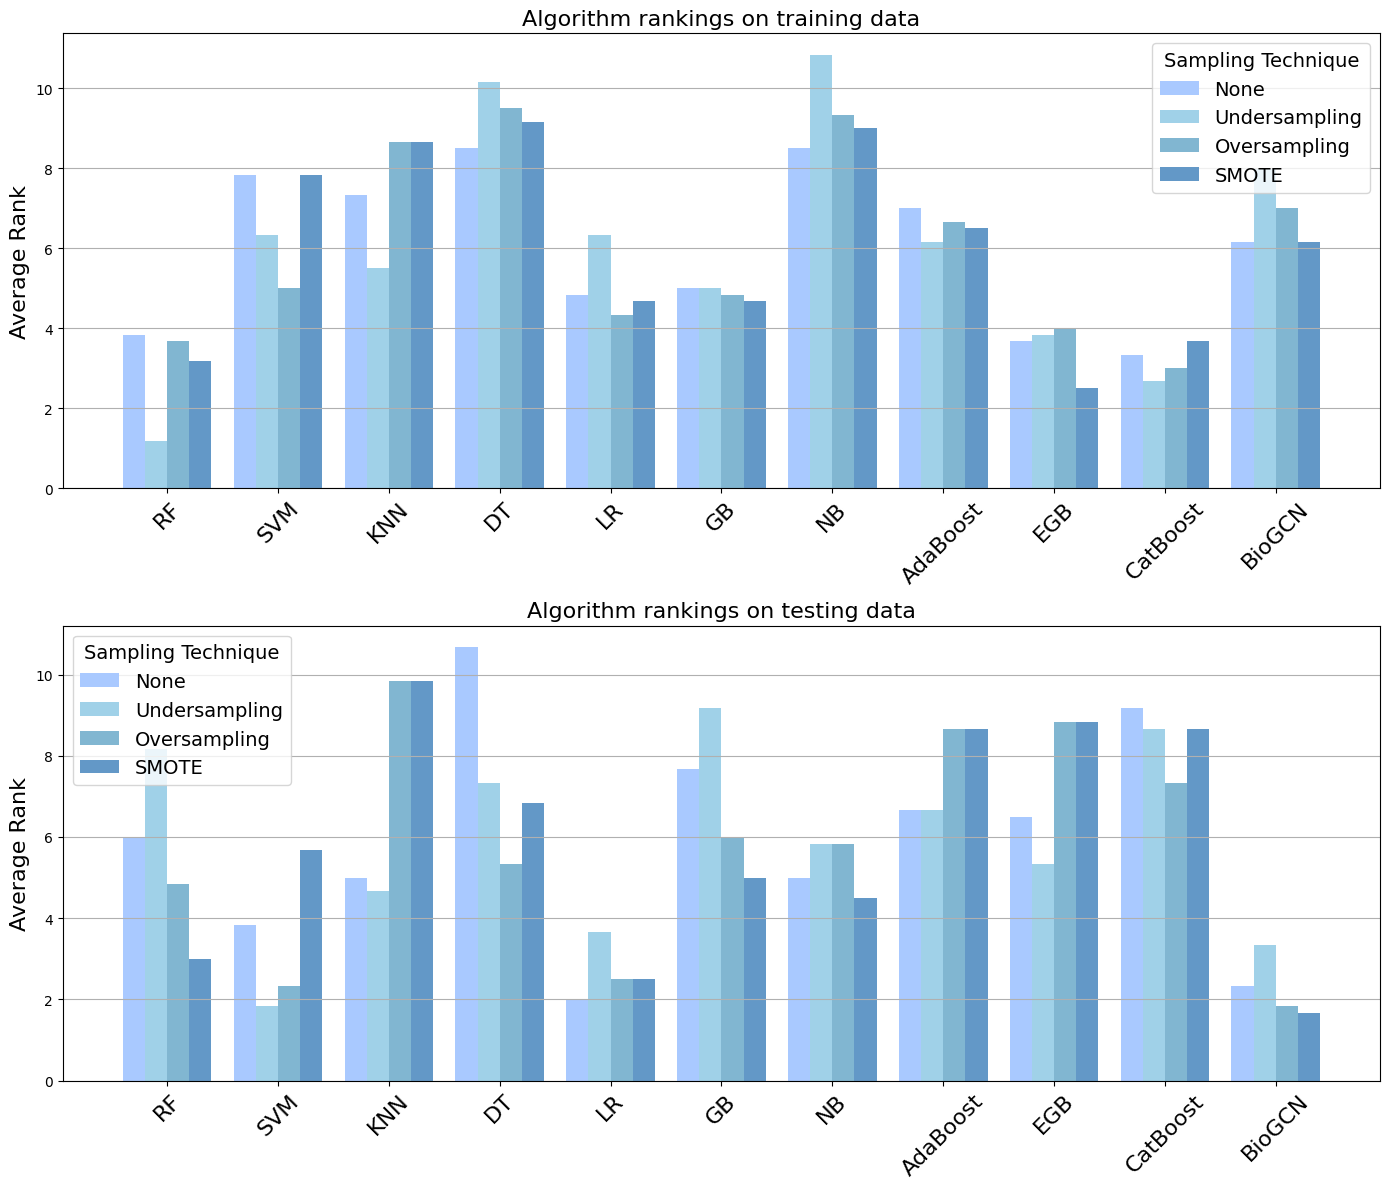

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
algorithms = ['RF', 'SVM', 'KNN', 'DT', 'LR', 'GB', 'NB', 'AdaBoost', 'EGB', 'CatBoost', 'BioGCN']
sampling_techniques = ['None', 'Undersampling', 'Oversampling', 'SMOTE']

# Training data
train_data = [
    [3.833333, 7.833333, 7.333333, 8.500000, 4.833333, 5.000000, 8.500000, 7.000000, 3.666667, 3.333333, 6.166667],
    [1.166667, 6.333333, 5.500000, 10.166667, 6.333333, 5.000000, 10.833333, 6.166667, 3.833333, 2.666667, 8.000000],
    [3.666667, 5.000000, 8.666667, 9.500000, 4.333333, 4.833333, 9.333333, 6.666667, 4.000000, 3.000000, 7.000000],
    [3.166667, 7.833333, 8.666667, 9.166667, 4.666667, 4.666667, 9.000000, 6.500000, 2.500000, 3.666667, 6.166667],
]

# Testing data 1
test_data = [
    [8.166667, 3.500000, 4.666667, 9.166667, 2.500000, 5.666667, 5.166667, 9.333333, 6.333333, 8.833333, 2.666667],
    [6.833333, 2.166667, 4.166667, 6.833333, 3.166667, 7.833333, 6.333333, 9.333333, 7.166667, 5.666667, 6.500000],
    [7.166667, 2.166667, 4.666667, 7.333333, 3.833333, 7.833333, 6.833333, 9.333333, 7.666667, 6.166667, 3.000000],
    [5.833333, 4.500000, 5.166667, 9.833333, 2.666667, 8.166667, 3.833333, 10.833333, 6.333333, 6.000000, 2.666667],
]

#testing data 2
test_data = [
    [6.000000, 3.833333, 5.000000, 10.666667, 2.000000, 7.666667, 5.000000, 6.666667, 6.500000, 9.166667, 2.333333],
    [8.166667, 1.833333, 4.666667, 7.333333, 3.666667, 9.166667, 5.833333, 6.666667, 5.333333, 8.666667, 3.333333],
    [4.833333, 2.333333, 9.833333, 5.333333, 2.500000, 6.000000, 5.833333, 8.666667, 8.833333, 7.333333, 1.833333],
    [3.000000, 5.666667, 9.833333, 6.833333, 2.500000, 5.000000, 4.500000, 8.666667, 8.833333, 8.666667, 1.666667],
]

# Creating DataFrames
train_df = pd.DataFrame(train_data, columns=algorithms, index=sampling_techniques)
test_df = pd.DataFrame(test_data, columns=algorithms, index=sampling_techniques)

# Plotting bar charts
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
width = 0.2  # width of bars
x = np.arange(len(algorithms))  # label locations

# Soft blue shades for sampling techniques
colors = ['#A9C9FF', '#A0D1E8', '#81B6D1', '#6398C7']  # light shades of blue
sampling_labels = ['None', 'Undersampling', 'Oversampling', 'SMOTE']

# Training data bar plot
for i, technique in enumerate(sampling_techniques):
    axes[0].bar(x + i*width, train_df.loc[technique], width, label=technique, color=colors[i])

axes[0].set_title("Algorithm rankings on training data", fontsize = 16)
#axes[0].set_xlabel("Algorithms")
axes[0].set_ylabel("Average Rank", fontsize = 16)
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(algorithms, rotation=45, fontsize = 16)
axes[0].legend(title="Sampling Technique", fontsize = 14, title_fontsize=14)
axes[0].grid(axis='y')

# Testing data bar plot
for i, technique in enumerate(sampling_techniques):
    axes[1].bar(x + i*width, test_df.loc[technique], width, label=technique, color=colors[i])

axes[1].set_title("Algorithm rankings on testing data", fontsize = 16)
#axes[1].set_xlabel("Algorithms")
axes[1].set_ylabel("Average Rank", fontsize = 16)
axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(algorithms, rotation=45, fontsize = 16)
axes[1].legend(title="Sampling Technique", fontsize = 14, title_fontsize=14)
axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HOB_revised1/algo_rank.eps', format='eps')

plt.show()


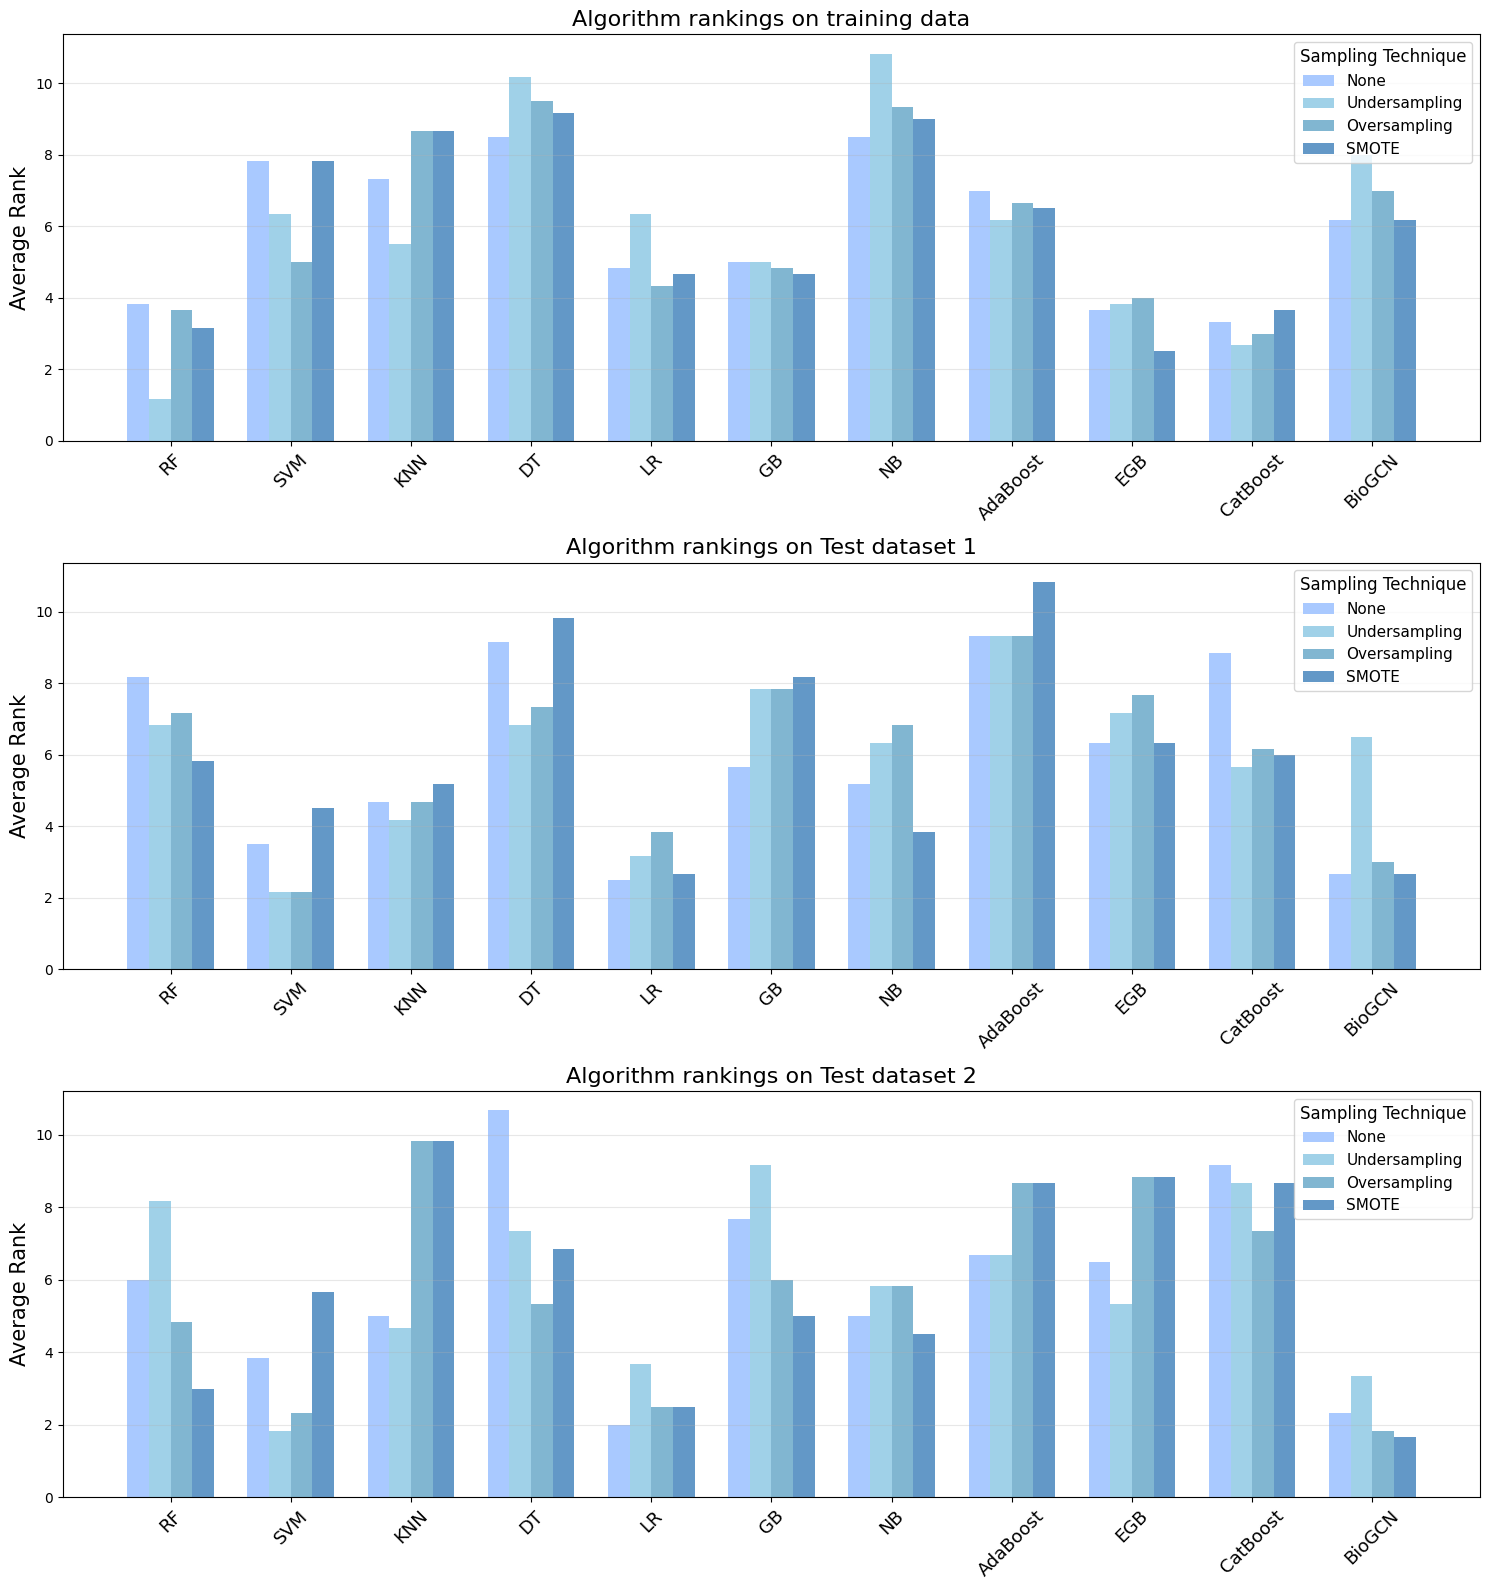

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

algorithms = ['RF', 'SVM', 'KNN', 'DT', 'LR', 'GB', 'NB', 'AdaBoost', 'EGB', 'CatBoost', 'BioGCN']
sampling_techniques = ['None', 'Undersampling', 'Oversampling', 'SMOTE']

# ---------------- Training ----------------
train_data = [
    [3.833333, 7.833333, 7.333333, 8.500000, 4.833333, 5.000000, 8.500000, 7.000000, 3.666667, 3.333333, 6.166667],
    [1.166667, 6.333333, 5.500000, 10.166667, 6.333333, 5.000000, 10.833333, 6.166667, 3.833333, 2.666667, 8.000000],
    [3.666667, 5.000000, 8.666667, 9.500000, 4.333333, 4.833333, 9.333333, 6.666667, 4.000000, 3.000000, 7.000000],
    [3.166667, 7.833333, 8.666667, 9.166667, 4.666667, 4.666667, 9.000000, 6.500000, 2.500000, 3.666667, 6.166667],
]

# ---------------- Test 1 ----------------
test_data1 = [
    [8.166667, 3.500000, 4.666667, 9.166667, 2.500000, 5.666667, 5.166667, 9.333333, 6.333333, 8.833333, 2.666667],
    [6.833333, 2.166667, 4.166667, 6.833333, 3.166667, 7.833333, 6.333333, 9.333333, 7.166667, 5.666667, 6.500000],
    [7.166667, 2.166667, 4.666667, 7.333333, 3.833333, 7.833333, 6.833333, 9.333333, 7.666667, 6.166667, 3.000000],
    [5.833333, 4.500000, 5.166667, 9.833333, 2.666667, 8.166667, 3.833333, 10.833333, 6.333333, 6.000000, 2.666667],
]

# ---------------- Test 2 ----------------
test_data2 = [
    [6.000000, 3.833333, 5.000000, 10.666667, 2.000000, 7.666667, 5.000000, 6.666667, 6.500000, 9.166667, 2.333333],
    [8.166667, 1.833333, 4.666667, 7.333333, 3.666667, 9.166667, 5.833333, 6.666667, 5.333333, 8.666667, 3.333333],
    [4.833333, 2.333333, 9.833333, 5.333333, 2.500000, 6.000000, 5.833333, 8.666667, 8.833333, 7.333333, 1.833333],
    [3.000000, 5.666667, 9.833333, 6.833333, 2.500000, 5.000000, 4.500000, 8.666667, 8.833333, 8.666667, 1.666667],
]

train_df = pd.DataFrame(train_data, columns=algorithms, index=sampling_techniques)
test1_df = pd.DataFrame(test_data1, columns=algorithms, index=sampling_techniques)
test2_df = pd.DataFrame(test_data2, columns=algorithms, index=sampling_techniques)

fig, axes = plt.subplots(3, 1, figsize=(15, 16))

width = 0.18
x = np.arange(len(algorithms))

colors = ['#A9C9FF', '#A0D1E8', '#81B6D1', '#6398C7']

titles = [
    'Algorithm rankings on training data',
    'Algorithm rankings on Test dataset 1',
    'Algorithm rankings on Test dataset 2'
]

dfs = [train_df, test1_df, test2_df]

for ax, df, title in zip(axes, dfs, titles):

    for i, technique in enumerate(sampling_techniques):
        ax.bar(
            x + i*width,
            df.loc[technique],
            width,
            label=technique,
            color=colors[i]
        )

    ax.set_title(title, fontsize=16)
    ax.set_ylabel('Average Rank', fontsize=15)
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(algorithms, rotation=45, fontsize=13)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(title='Sampling Technique', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HOB_revised1/algo_rank_threeplots.png',
            dpi=600, bbox_inches='tight')
plt.savefig('/content/drive/MyDrive/HOB_revised1/algo_rank_threeplots.eps',
            format='eps', bbox_inches='tight')

plt.show()

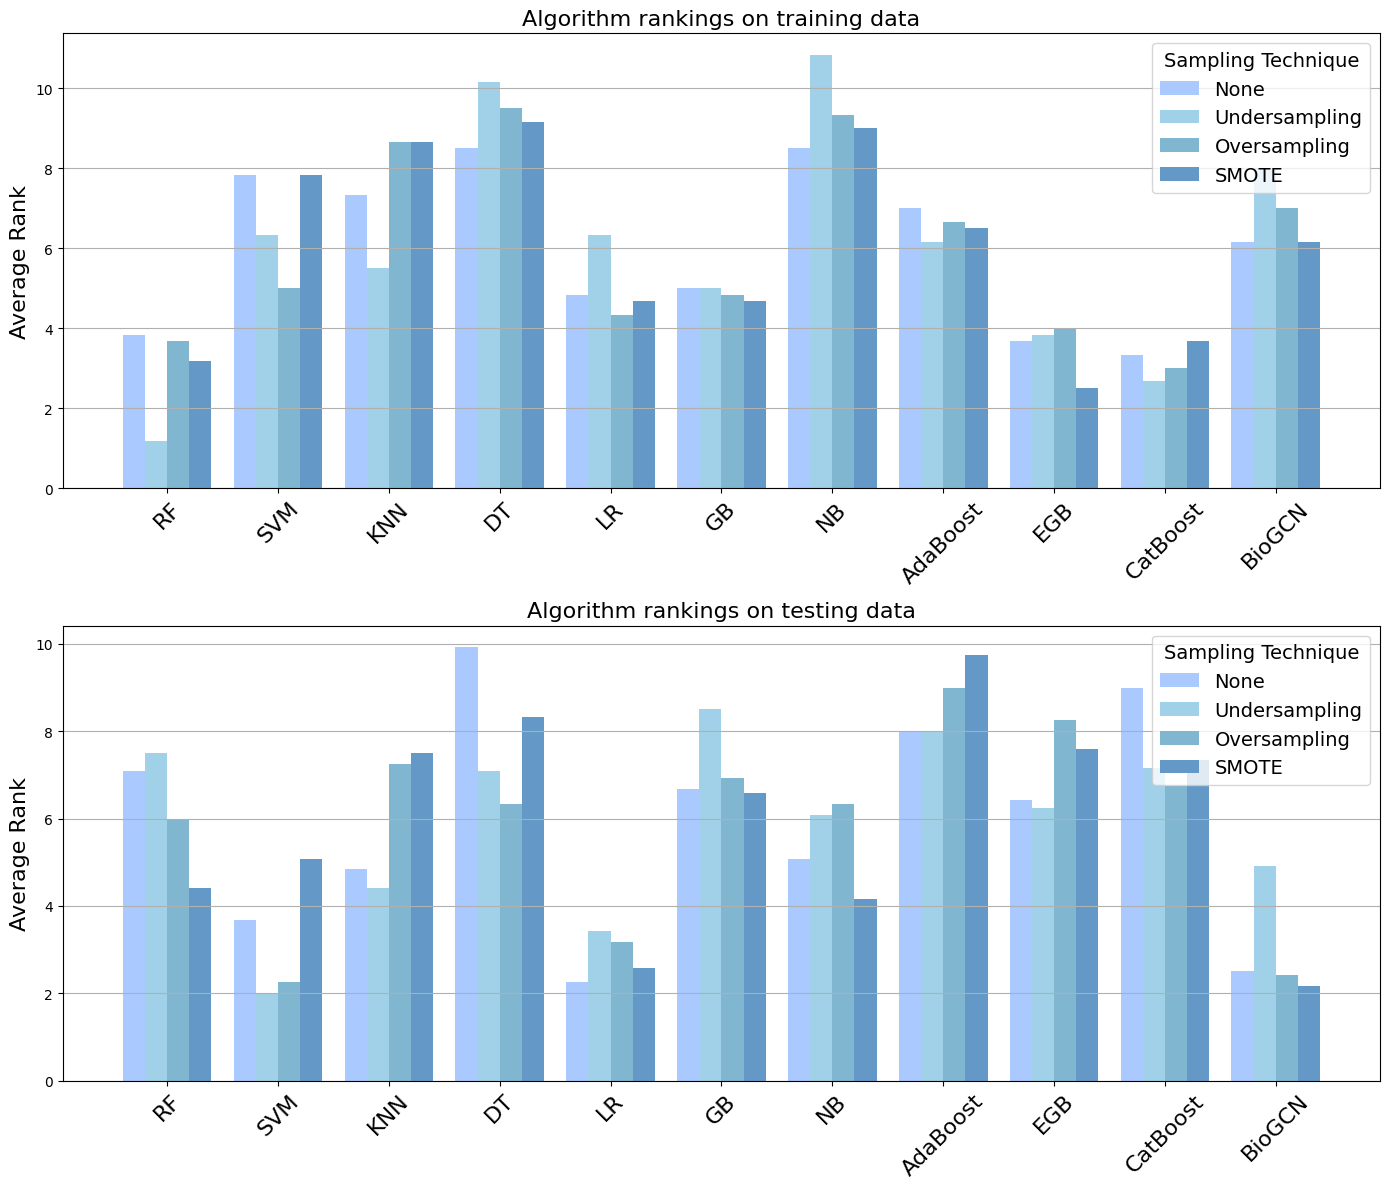

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
algorithms = ['RF', 'SVM', 'KNN', 'DT', 'LR', 'GB', 'NB', 'AdaBoost', 'EGB', 'CatBoost', 'BioGCN']
sampling_techniques = ['None', 'Undersampling', 'Oversampling', 'SMOTE']

# Training data
train_data = [
    [3.833333, 7.833333, 7.333333, 8.500000, 4.833333, 5.000000, 8.500000, 7.000000, 3.666667, 3.333333, 6.166667],
    [1.166667, 6.333333, 5.500000, 10.166667, 6.333333, 5.000000, 10.833333, 6.166667, 3.833333, 2.666667, 8.000000],
    [3.666667, 5.000000, 8.666667, 9.500000, 4.333333, 4.833333, 9.333333, 6.666667, 4.000000, 3.000000, 7.000000],
    [3.166667, 7.833333, 8.666667, 9.166667, 4.666667, 4.666667, 9.000000, 6.500000, 2.500000, 3.666667, 6.166667],
]

# Testing data average of test 1 and test2
test_data = [
    # None
    [7.083333, 3.666667, 4.833334, 9.916667, 2.250000,
     6.666667, 5.083333, 8.000000, 6.416667, 9.000000, 2.500000],

    # Undersampling
    [7.500000, 2.000000, 4.416667, 7.083333, 3.416667,
     8.500000, 6.083333, 8.000000, 6.250000, 7.166667, 4.916667],

    # Oversampling
    [6.000000, 2.250000, 7.249999, 6.333333, 3.166667,
     6.916667, 6.333333, 9.000000, 8.249999, 6.749999, 2.416667],

    # SMOTE
    [4.416667, 5.083333, 7.499999, 8.333333, 2.583333,
     6.583333, 4.166667, 9.749999, 7.583333, 7.333333, 2.166667],

]



# Creating DataFrames
train_df = pd.DataFrame(train_data, columns=algorithms, index=sampling_techniques)
test_df = pd.DataFrame(test_data, columns=algorithms, index=sampling_techniques)

# Plotting bar charts
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
width = 0.2  # width of bars
x = np.arange(len(algorithms))  # label locations

# Soft blue shades for sampling techniques
colors = ['#A9C9FF', '#A0D1E8', '#81B6D1', '#6398C7']  # light shades of blue
sampling_labels = ['None', 'Undersampling', 'Oversampling', 'SMOTE']

# Training data bar plot
for i, technique in enumerate(sampling_techniques):
    axes[0].bar(x + i*width, train_df.loc[technique], width, label=technique, color=colors[i])

axes[0].set_title("Algorithm rankings on training data", fontsize = 16)
#axes[0].set_xlabel("Algorithms")
axes[0].set_ylabel("Average Rank", fontsize = 16)
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(algorithms, rotation=45, fontsize = 16)
axes[0].legend(title="Sampling Technique", fontsize = 14, title_fontsize=14)
axes[0].grid(axis='y')

# Testing data bar plot
for i, technique in enumerate(sampling_techniques):
    axes[1].bar(x + i*width, test_df.loc[technique], width, label=technique, color=colors[i])

axes[1].set_title("Algorithm rankings on testing data", fontsize = 16)
#axes[1].set_xlabel("Algorithms")
axes[1].set_ylabel("Average Rank", fontsize = 16)
axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(algorithms, rotation=45, fontsize = 16)
axes[1].legend(title="Sampling Technique", fontsize = 14, title_fontsize=14)
axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HOB_revised1/algo_rank.eps', format='eps')

plt.show()
